# SIF -> GPP conversion factor: evaluation plots

Diagnostics for `sif_gpp_conversion.py` -- linear-through-origin vs. saturating (Michaelis-Menten style) fits of coincident FLUXNET GPP against ECOCO3 SIF. Reuses the fitting functions from `sif_gpp_conversion.py` directly rather than re-implementing them, so this notebook always reflects the same fit the production pipeline (or `01_Analysis_V6_SAT.ipynb` for the saturating variant) uses.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import analysis_functions as af
import plot_scripts
import sif_gpp_conversion as sgc

os.makedirs('figures/C2_validation', exist_ok=True)

## Build the coincident dataset (half-hourly) and fit all three models

In [11]:
df_wue_hh_fluxnet, df_wue_hh_ecoco3 = sgc.load_data()

pixel_matches = af.build_tower_pixel_matches(
    df_wue_hh_fluxnet, df_wue_hh_ecoco3, radius_km=sgc.RADIUS_KM, lat_col='Lat', lon_col='Lon'
)

df_coincident = af.make_coincident(
    df_wue_hh_fluxnet, df_wue_hh_ecoco3, pixel_matches,
    tolerance=pd.Timedelta('0.25h'), extra_eco_cols=['SIF'],
)
df_coincident = df_coincident.dropna(subset=['SIF', 'GPP_FLUX', 'GPP_ECO'])
df_coincident = df_coincident[(df_coincident['SIF'] > 0) & (df_coincident['GPP_FLUX'] > 0)]
print(f'{len(df_coincident):,} coincident half-hourly points')
df_coincident['Veg'].value_counts()

312 coincident half-hourly points


Veg
GRA    148
ENF     43
CRO     28
DBF     25
WSA     24
EBF     13
MF      11
OSH     10
SAV      5
WET      5
Name: count, dtype: int64

In [12]:
sif = df_coincident['SIF'].values
gpp_flux = df_coincident['GPP_FLUX'].values

k_global, r2_global = sgc.fit_through_origin(sif, gpp_flux)
m_sat, a_sat, r2_sat, rmse_sat = sgc.fit_saturating(sif, gpp_flux)

gpp_pred_linear = k_global * sif
gpp_pred_saturating = (m_sat * sif) / (a_sat + sif)
rmse_linear = np.sqrt(np.mean((gpp_flux - gpp_pred_linear) ** 2))
ss_tot = np.sum((gpp_flux - gpp_flux.mean()) ** 2)

# GPP_ECO (read from the production CSV) is now the SAME number as
# gpp_pred_linear, since the production pipeline already uses this
# empirically-fit k -- kept here only as a consistency check.
gpp_eco_current = df_coincident['GPP_ECO'].values
assert np.allclose(gpp_eco_current, gpp_pred_linear, rtol=1e-3), 'production GPP no longer matches the refit k -- investigate'

# The genuinely different historical baseline: before this session's fix, a
# bug (conversion_factors.get(row['IGBP_MODIS'], 13.63) looked up an integer
# IGBP code against a string-keyed dict) meant every row silently fell
# through to the flat default 13.63 regardless of vegetation type -- this
# was never actually vegetation-specific. Confirmed against the pre-fix
# backup CSV.
gpp_eco_prefix = sif * 13.63
rmse_prefix = np.sqrt(np.mean((gpp_flux - gpp_eco_prefix) ** 2))
r2_prefix = 1 - np.sum((gpp_flux - gpp_eco_prefix) ** 2) / ss_tot

print(f'Pre-fix (flat 13.63, buggy):    R2={r2_prefix:.3f}   RMSE={rmse_prefix:.2f}')
print(f'Linear (production, k={k_global:.3f}): R2={r2_global:.3f}   RMSE={rmse_linear:.2f}')
print(f'Saturating: m={m_sat:.3f} a={a_sat:.3f}  (initial slope m/a={m_sat/a_sat:.3f})   R2={r2_sat:.3f}   RMSE={rmse_sat:.2f}')

Pre-fix (flat 13.63, buggy):    R2=0.211   RMSE=7.51
Linear (production, k=14.446): R2=0.216   RMSE=7.49
Saturating: m=34.480 a=1.288  (initial slope m/a=26.771)   R2=0.306   RMSE=7.04


## Plot A -- SIF vs. FLUXNET GPP, colored by vegetation type, both fits overlaid

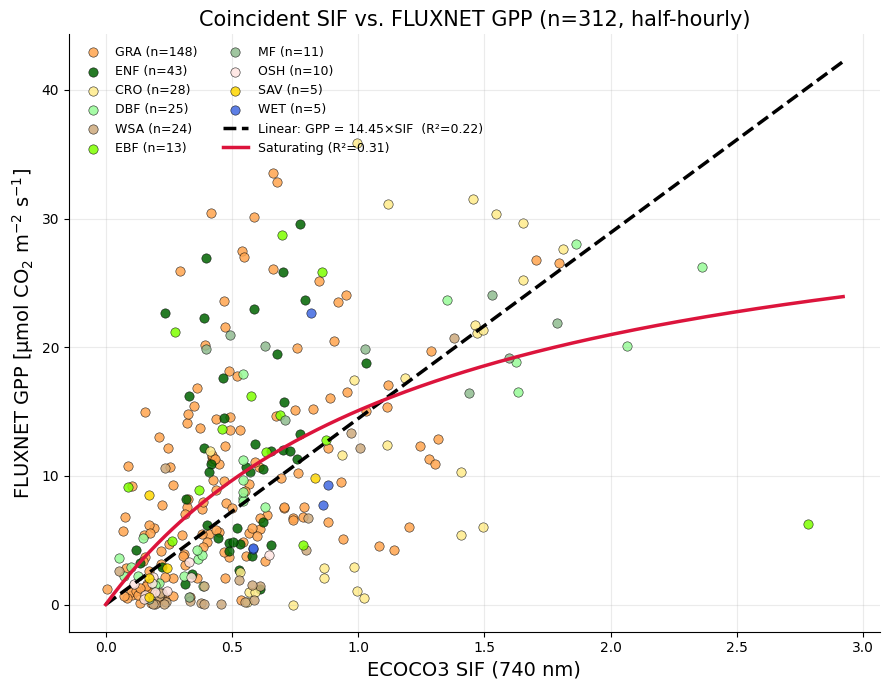

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

veg_order = df_coincident['Veg'].value_counts().index.tolist()
for veg in veg_order:
    sub = df_coincident[df_coincident['Veg'] == veg]
    color = plot_scripts.veg_color_palette.get(veg, 'gray')
    ax.scatter(sub['SIF'], sub['GPP_FLUX'], s=45, color=color, edgecolor='black',
               linewidth=0.4, alpha=0.85, label=f'{veg} (n={len(sub)})')

x_line = np.linspace(0, sif.max() * 1.05, 200)
ax.plot(x_line, k_global * x_line, color='black', lw=2.5, linestyle='--',
        label=f'Linear: GPP = {k_global:.2f}\u00d7SIF  (R\u00b2={r2_global:.2f})')
ax.plot(x_line, (m_sat * x_line) / (a_sat + x_line), color='crimson', lw=2.5,
        label=f'Saturating (R\u00b2={r2_sat:.2f})')

ax.set_xlabel('ECOCO3 SIF (740 nm)', fontsize=14)
ax.set_ylabel('FLUXNET GPP [\u00b5mol CO$_2$ m$^{-2}$ s$^{-1}$]', fontsize=14)
ax.set_title(f'Coincident SIF vs. FLUXNET GPP (n={len(df_coincident)}, half-hourly)', fontsize=15)
ax.legend(fontsize=9, ncol=2, frameon=False, loc='upper left')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/C2_validation/sif_gpp_fit_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot B -- residuals for each fit

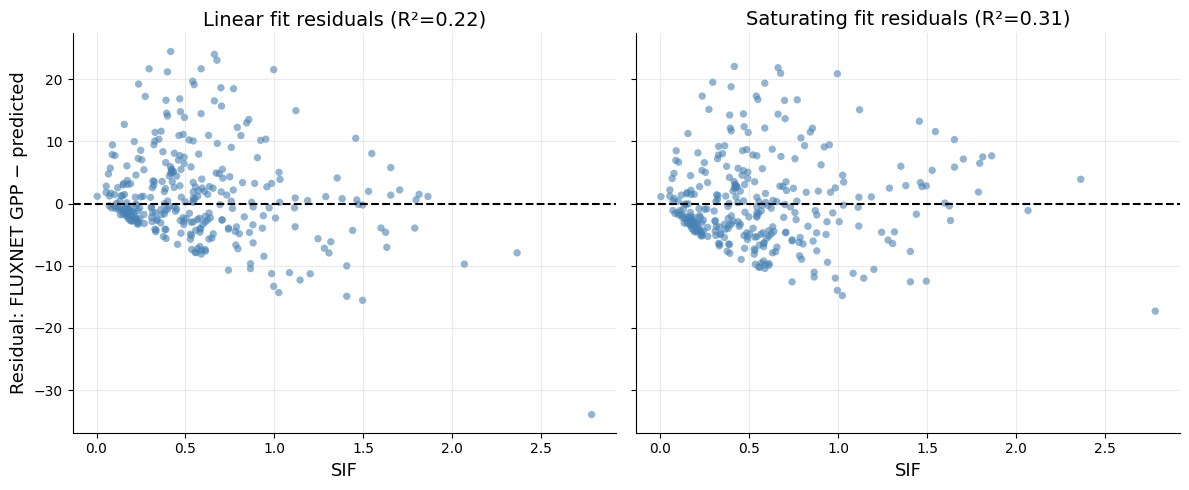

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

resid_linear = gpp_flux - gpp_pred_linear
resid_saturating = gpp_flux - gpp_pred_saturating

for ax, resid, label, r2 in zip(axes, [resid_linear, resid_saturating],
                                 ['Linear', 'Saturating'], [r2_global, r2_sat]):
    ax.scatter(sif, resid, s=28, alpha=0.6, color='steelblue', edgecolor='none')
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('SIF', fontsize=13)
    ax.set_title(f'{label} fit residuals (R\u00b2={r2:.2f})', fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Residual: FLUXNET GPP \u2212 predicted', fontsize=13)
plt.tight_layout()
plt.savefig('figures/C2_validation/sif_gpp_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot C -- per-vegetation empirical factor and fit quality

Context only -- not what's used downstream. Shows how much a single global factor is averaging over, and how reliable (by sample size) each vegetation-specific estimate actually is.

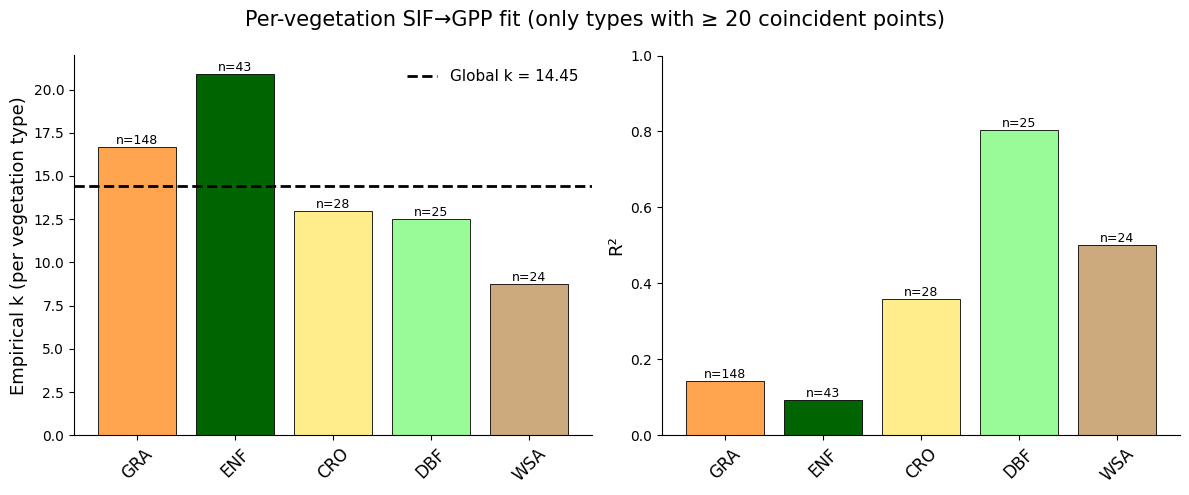

In [15]:
by_veg = pd.read_csv('tables/sif_gpp_conversion_by_veg.csv').sort_values('n', ascending=False)
colors = [plot_scripts.veg_color_palette.get(v, 'gray') for v in by_veg['Veg']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars0 = axes[0].bar(by_veg['Veg'], by_veg['k_empirical'], color=colors, edgecolor='black', linewidth=0.6)
axes[0].axhline(k_global, color='black', linestyle='--', lw=2, label=f'Global k = {k_global:.2f}')
axes[0].set_ylabel('Empirical k (per vegetation type)', fontsize=13)
axes[0].legend(frameon=False, fontsize=11)

bars1 = axes[1].bar(by_veg['Veg'], by_veg['r2'], color=colors, edgecolor='black', linewidth=0.6)
axes[1].set_ylabel('R\u00b2', fontsize=13)
axes[1].set_ylim(0, 1)

for ax, bars in zip(axes, [bars0, bars1]):
    for bar, n in zip(bars, by_veg['n']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'n={n}',
                ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Per-vegetation SIF\u2192GPP fit (only types with \u2265 20 coincident points)', fontsize=15)
plt.tight_layout()
plt.savefig('figures/C2_validation/sif_gpp_by_vegetation.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot D -- predicted vs. observed GPP, three methods side by side

1:1 line = perfect agreement. Same coincident points, same axes, so panels are directly comparable.

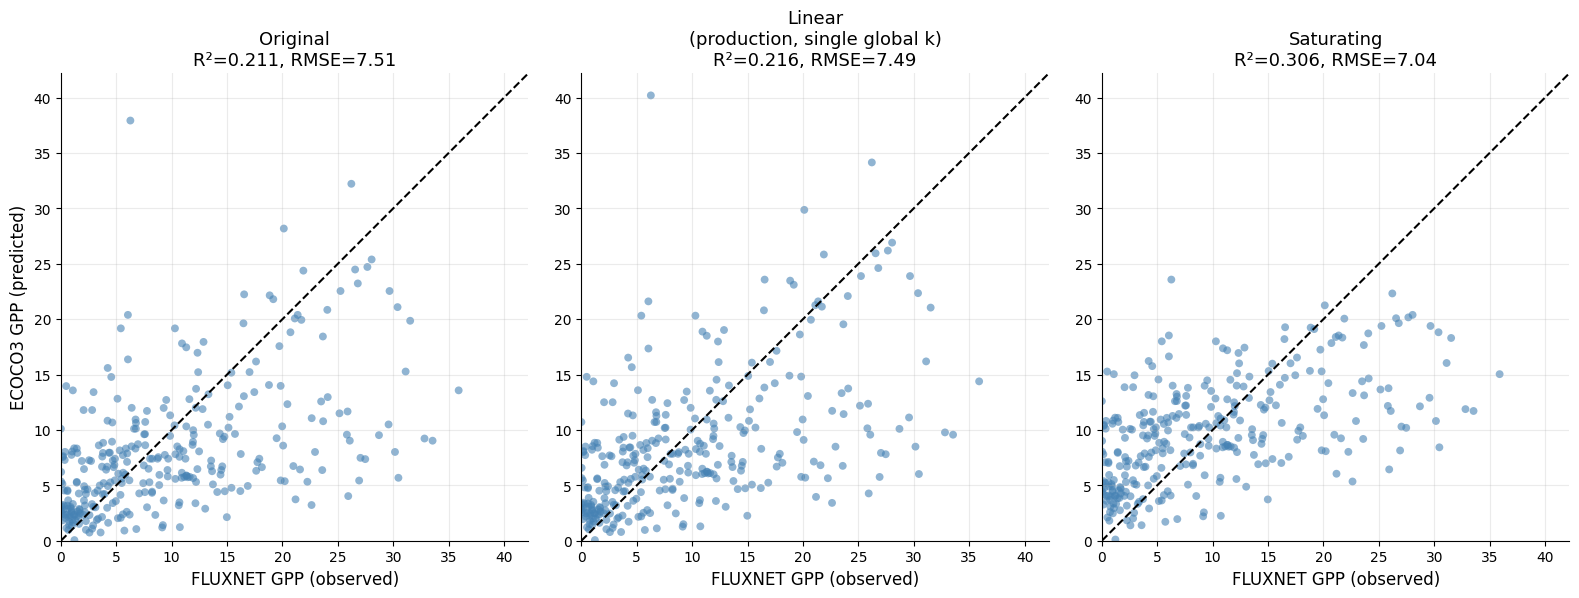

In [16]:
methods = [
    ('Original', gpp_eco_prefix, r2_prefix, rmse_prefix),
    ('Linear\n(production, single global k)', gpp_pred_linear, r2_global, rmse_linear),
    ('Saturating', gpp_pred_saturating, r2_sat, rmse_sat),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
lims = [0, max(gpp_flux.max(), gpp_eco_prefix.max(), gpp_pred_linear.max(), gpp_pred_saturating.max()) * 1.05]

for ax, (name, pred, r2, rmse) in zip(axes, methods):
    ax.scatter(gpp_flux, pred, s=32, alpha=0.6, color='steelblue', edgecolor='none')
    ax.plot(lims, lims, color='black', lw=1.5, linestyle='--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel('FLUXNET GPP (observed)', fontsize=12)
    ax.set_title(f'{name}\nR²={r2:.3f}, RMSE={rmse:.2f}', fontsize=13)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.25)

axes[0].set_ylabel('ECOCO3 GPP (predicted)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/C2_validation/sif_gpp_predicted_vs_observed.png', dpi=300, bbox_inches='tight')
plt.show()

## Daily-resolution robustness check

Same comparison using daily-aggregated coincident data -- less noisy, independent check on whether the fit (and the linear-vs-saturating gap) holds up at a coarser resolution.

In [17]:
df_wue_daily_fluxnet = pd.read_csv('data/FLUXNET_Data_Shuttle/WUE_combined_daily_shuttle.csv')
df_wue_daily_fluxnet['TIMESTAMP'] = pd.to_datetime(df_wue_daily_fluxnet['TIMESTAMP'])
df_wue_daily_fluxnet = df_wue_daily_fluxnet.rename(columns={'GPP_DT_VUT_USTAR50': 'GPP', 'LE_CORR_kg_H2O': 'ET', 'Long': 'Lon'})

df_wue_daily_ecoco3 = pd.read_csv('data/ECOCO3_cleaned/ECOCO3_V2_df_wue_daily_fullset.csv')
df_wue_daily_ecoco3['LocalTime'] = pd.to_datetime(df_wue_daily_ecoco3['LocalTime'], format='%Y-%m-%d %H:%M:%S')
df_wue_daily_ecoco3 = df_wue_daily_ecoco3[df_wue_daily_ecoco3['IGBP_class_MODIS'] == df_wue_daily_ecoco3['IGBP_class_VIIRS']]
df_wue_daily_ecoco3 = df_wue_daily_ecoco3.rename(columns={'IGBP_class_MODIS': 'Veg'})
df_wue_daily_ecoco3['WUE'] = df_wue_daily_ecoco3['WUE_gCkgH20']
df_wue_daily_ecoco3 = df_wue_daily_ecoco3.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['GPP', 'ET', 'WUE', 'SIF', 'Veg', 'Lat', 'Lon'])
df_wue_daily_ecoco3['TIMESTAMP'] = df_wue_daily_ecoco3['LocalTime']

pixel_matches_daily = af.build_tower_pixel_matches(
    df_wue_daily_fluxnet, df_wue_daily_ecoco3, radius_km=sgc.RADIUS_KM, lat_col='Lat', lon_col='Lon')
df_coincident_daily = af.make_coincident(
    df_wue_daily_fluxnet, df_wue_daily_ecoco3, pixel_matches_daily,
    tolerance=pd.Timedelta('12h'), normalize_dates=True, extra_eco_cols=['SIF'])
df_coincident_daily = df_coincident_daily.dropna(subset=['SIF', 'GPP_FLUX'])
df_coincident_daily = df_coincident_daily[(df_coincident_daily['SIF'] > 0) & (df_coincident_daily['GPP_FLUX'] > 0)]

sif_d = df_coincident_daily['SIF'].values
gpp_d = df_coincident_daily['GPP_FLUX'].values
k_daily, r2_lin_daily = sgc.fit_through_origin(sif_d, gpp_d)
m_daily, a_daily, r2_sat_daily, rmse_sat_daily = sgc.fit_saturating(sif_d, gpp_d)
print(f'n={len(df_coincident_daily)}  linear k={k_daily:.3f} R2={r2_lin_daily:.3f}  |  '
      f'saturating m/a={m_daily/a_daily:.3f} R2={r2_sat_daily:.3f}')

n=355  linear k=14.026 R2=0.258  |  saturating m/a=26.561 R2=0.363


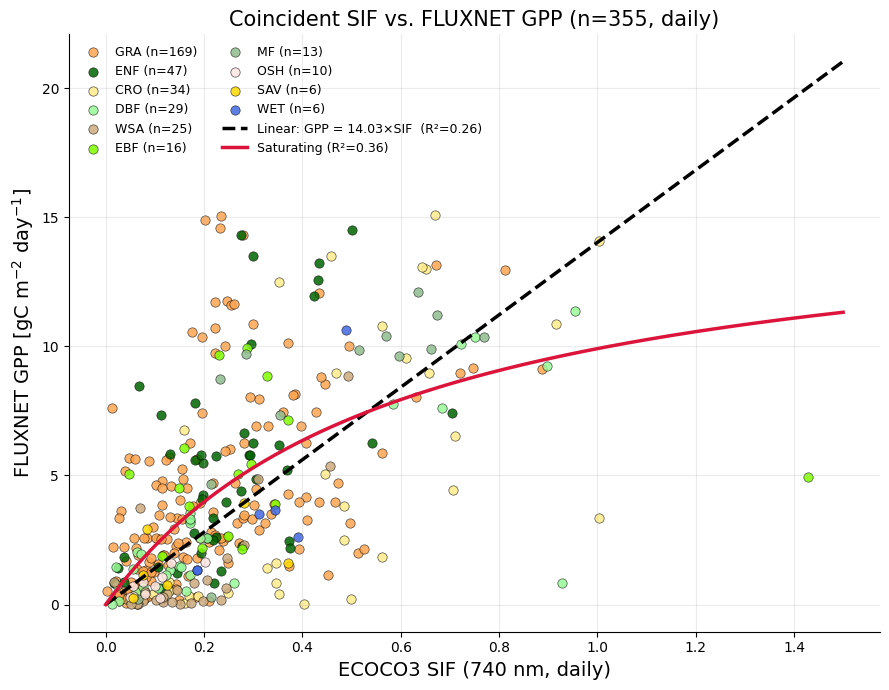

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

for veg in df_coincident_daily['Veg'].value_counts().index:
    sub = df_coincident_daily[df_coincident_daily['Veg'] == veg]
    color = plot_scripts.veg_color_palette.get(veg, 'gray')
    ax.scatter(sub['SIF'], sub['GPP_FLUX'], s=45, color=color, edgecolor='black',
               linewidth=0.4, alpha=0.85, label=f'{veg} (n={len(sub)})')

x_line_d = np.linspace(0, sif_d.max() * 1.05, 200)
ax.plot(x_line_d, k_daily * x_line_d, color='black', lw=2.5, linestyle='--',
        label=f'Linear: GPP = {k_daily:.2f}\u00d7SIF  (R\u00b2={r2_lin_daily:.2f})')
ax.plot(x_line_d, (m_daily * x_line_d) / (a_daily + x_line_d), color='crimson', lw=2.5,
        label=f'Saturating (R\u00b2={r2_sat_daily:.2f})')

ax.set_xlabel('ECOCO3 SIF (740 nm, daily)', fontsize=14)
ax.set_ylabel('FLUXNET GPP [gC m$^{-2}$ day$^{-1}$]', fontsize=14)
ax.set_title(f'Coincident SIF vs. FLUXNET GPP (n={len(df_coincident_daily)}, daily)', fontsize=15)
ax.legend(fontsize=9, ncol=2, frameon=False, loc='upper left')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/C2_validation/sif_gpp_fit_comparison_daily.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

- **Plot A / daily plot**: does the saturating curve visibly track the upper-SIF points better than the line, or is the R\u00b2 gain driven by a few points?
- **Plot B**: linear residuals should show a visible trend (over-predicting at low SIF, under- or over-predicting at high SIF) if the true relationship saturates; saturating residuals should look flatter/more random if the model is a genuine improvement rather than overfitting.
- **Plot C**: per-vegetation n -- treat any bar with n<20 as unreliable regardless of its R\u00b2 or k value.
- **Plot D**: which method's point cloud hugs the 1:1 line most tightly, and whether any method is systematically biased above/below it at high GPP.